<div align="center">

# PROYECTO FINAL
## **Dataset de Películas**

### Minería de Datos  



**Fuente:** Hugging Face – TMDB Movies Dataset



**Integrantes**  
Juan Daniel Ramirez Mojica

Maria Paula Carvajal Martinez


Paula Daniela Guzman Zabala

Karem Nataly Sierra Molina




**Universidad**  
Universidad Nacional de Colombia


**Fecha**  
25/02/2026  

</div>


##**1. Comprensión del problema y del dataset**

Fuente del Dataset:

[1] Datadruids, “Full TMDB Movies Dataset,” HuggingFace.co, 2026. Available: https://huggingface.co/datasets/ada-datadruids/full_tmdb_movies_dataset. [Accessed: Feb. 24, 2026]


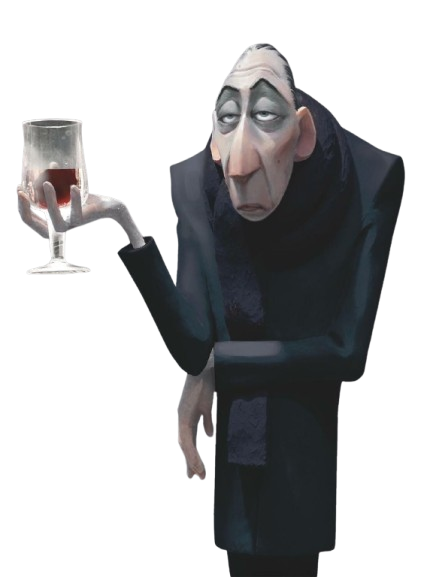

##  ¿Qué estamos analizando?

- El cine es una de las industrias culturales más grandes del mundo, con millones de títulos producidos a lo largo de la historia en decenas de idiomas y géneros.
- En este proyecto se analiza un conjunto de datos masivo con información de películas extraída de bases de datos como TMDB (The Movie Database).
- El dataset contiene 1,142,342 registros de películas (filas) y 24 variables (columnas) que describen características como título, géneros, popularidad, presupuesto, recaudación, sinopsis y palabras clave.
- Se incluyen tanto variables numéricas (votos, ingresos, duración, popularidad) como variables de texto libre (sinopsis, géneros, keywords), lo que permite combinar técnicas de análisis estadístico con procesamiento de lenguaje natural (NLP).
- El objetivo principal es construir un sistema de recomendación de películas basado en......
- El análisis exploratorio busca comprender la distribución del catálogo, identificar patrones en géneros, épocas y popularidad y preparar los datos para .....

**Presentación (diapositivas)**: https://www.canva.com/design/DAHCP12ebtc/5khUpBy5Q0LfSIDzacsflA/edit

## **2. Inspección inicial de los datos**

### **2.1. Recolección de Datos Iniciales**


El conjunto de datos fue descargado directamente desde Hugging Face
 mediante la librería datasets, permitiendo una integración sencilla y reproducible en el entorno de análisis.

In [ ]:
#pip install datasets

In [ ]:
from datasets import load_dataset
import pandas as pd

In [ ]:

# Cargar el dataset desde Hugging Face
dataset = load_dataset("ada-datadruids/full_tmdb_movies_dataset")

# Ver splits disponibles
print(dataset)

Cargamos el dataset

In [ ]:
# Convertir el split "train" a pandas
df = dataset["train"].to_pandas()

print(f"Se cargaron {len(df)} filas.")


A continuación veremos archivos descargados, junto a la creación de la ruta correcta, y la carga de datos:

In [ ]:
df.head()

In [ ]:
df.tail()

## 2.2. Análisis de Calidad de Datos

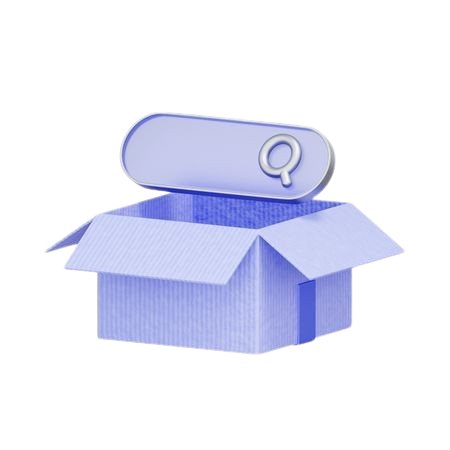

In [ ]:
df.shape

In [ ]:
df.info()

Revisamos los valores faltantes

In [ ]:
df.isnull().sum()

Información general de nuestro dataset

In [ ]:

print(f"\nDimensiones: {df.shape[0]} filas x {df.shape[1]} columnas")
print(f"\n{'-'*60}")
print("Tipos de datos:")
print(df.dtypes.value_counts())

## **2.3. Descripción de los Datos**

In [ ]:
df.describe()



- El dataset contiene 1,142,342 registros y 24 variables de producción, popularidad y metadata cinematográfica.
- La puntuación promedio (vote_average) de las películas es de apenas 1.87 sobre 10, lo cual refleja que la gran mayoría de títulos en el dataset tienen muy pocos o ningún voto — la mediana es 0, indicando que más del 50% de las películas aún no han sido calificadas por usuarios.
- La duración promedio (runtime) ronda los 47 minutos, aunque con alta variabilidad: hay títulos con duración negativa o cero (datos a limpiar) y un máximo de 14,400 minutos, lo que sugiere la presencia de outliers importantes.

- El presupuesto y la recaudación presentan una distribución extremadamente sesgada: la mediana de ambos es 0, lo que indica que la mayoría de películas no tiene datos financieros registrados, mientras que unos pocos blockbusters concentran valores de hasta 3,000 millones en recaudación.
- La popularidad promedio es de 1.23, pero con una desviación estándar de 7.57 y un máximo de ~2,994, lo que evidencia que unas pocas películas concentran casi toda la atención, siguiendo una distribución de tipo ley de potencia (power law).
- En cuanto a completitud de datos, columnas clave para el sistema de recomendación presentan valores nulos significativos: overview tiene ~232K nulos (20%), genres ~459K nulos (40%), y keywords ~833K nulos (73%) — estas columnas deberán tratarse antes del modelado semántico.
- Los tipos de datos incluyen 5 variables enteras, 2 flotantes, 1 booleana y 16 de tipo objeto (texto), lo que demanda preprocesamiento tanto numérico como de lenguaje natural para construir los embeddings.


## **3. Exploración de Datos (Análisis Estadístico)**

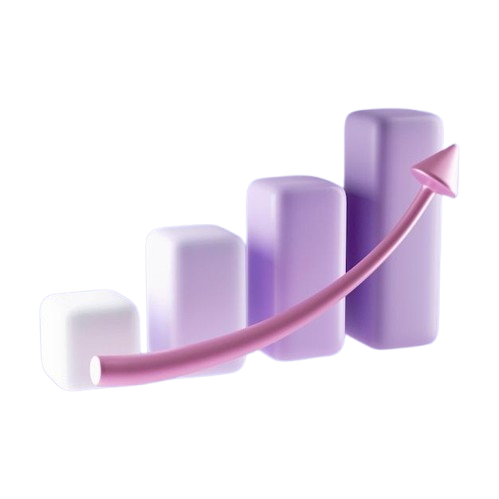

¿Qué representa cada medida que estamos obteniendo en el siguiente código?

| Medida              | Qué significa                    | Para que sirve                |
| ------------------- | -------------------------------- | ----------------------------- |
| **Media**           | Promedio                         | Valor típico general          |
| **Mediana (Q2)**    | Valor central                    | Evita sesgos por extremos     |
| **Moda**            | Valor más repetido               | Detecta valores dominantes    |
| **Desv. Std**       | Qué tanto se dispersan los datos | Variabilidad                  |
| **Varianza**        | Dispersión al cuadrado           | Confirmar variabilidad        |
| **Mínimo / Máximo** | Valores extremos                 | Rango real                    |
| **Q1 / Q3**         | 25% y 75%                        | Dónde se concentra la mayoría |
| **Rango**           | Máx - mín                        | Amplitud total                |


En esta sección se analizan las principales características estadísticas del conjunto de datos, con el fin de comprender la distribución de las variables, identificar valores atípicos y observar tendencias generales en la información de los pacientes.

In [ ]:
import pandas as pd

"""
Variables numéricas continuas a analizar
"""

variables = [
    "vote_average",   # Puntuación promedio de la película
    "vote_count",     # Número de votos recibidos
    "revenue",        # Recaudación en taquilla
    "runtime",        # Duración en minutos
    "budget",         # Presupuesto de producción
    "popularity"      # Índice de popularidad TMDB
]


def resumen_estadistico(df, columnas):
    resumen = pd.DataFrame({
        "Media": df[columnas].mean(),
        "Mediana": df[columnas].median(),
        "Moda": df[columnas].mode().iloc[0],
        "Desv. Std": df[columnas].std(),
        "Varianza": df[columnas].var(),
        "Mínimo": df[columnas].min(),
        "Q1 (25%)": df[columnas].quantile(0.25),
        "Q2 (50%)": df[columnas].quantile(0.50),
        "Q3 (75%)": df[columnas].quantile(0.75),
        "Máximo": df[columnas].max(),
        "Rango": df[columnas].max() - df[columnas].min()
    })

    return resumen.round(2)


resumen = resumen_estadistico(df, variables)

resumen

¿Qué podemos interpretar de estas medidas obtenidas?

### Interpretación del resumen estadístico

- **Puntuación promedio (vote_average):**
  - La media es de 1.87 sobre 10, pero la mediana es 0, lo que indica que más del 50% de las películas no tienen ninguna calificación registrada.
  - El grupo de películas efectivamente valoradas tiende a concentrarse entre 4.7 y 10, sugiriendo que cuando hay votos, la calidad percibida es moderada-alta.

- **Número de votos (vote_count):**
  - Promedio de ~19 votos por película, pero con mediana 0, confirmando que la mayoría de títulos son prácticamente desconocidos o sin interacción de usuarios.
  - Unos pocos blockbusters concentran hasta 34,495 votos, generando una distribución extremadamente sesgada a la derecha.

- **Recaudación (revenue):**
  - La mediana es \$0, lo que refleja que la gran mayoría de películas no tiene datos de taquilla registrados, no necesariamente que no recaudaron nada.
  - Se detectan valores negativos (-12) que corresponden a errores de datos a corregir, y un máximo de \$3,000 millones perteneciente a un grupo muy reducido de superproducciones.

- **Duración (runtime):**
  - Promedio de ~47 minutos con mediana de 22 minutos, lo que sugiere que el dataset incluye una gran cantidad de cortometrajes además de largometrajes.
  - Se detectan valores negativos (-28 minutos) y un máximo de 14,400 minutos, ambos outliers claros que requieren limpieza.

- **Presupuesto (budget):**
  - La mediana es \$0, indicando ausencia masiva de datos financieros en el catálogo general.
  - Solo una fracción pequeña de producciones tiene presupuestos registrados, con un máximo de \$1,000 millones.

- **Popularidad (popularity):**
  - La mediana es 0.6 y el 75% de las películas no supera 0.88, mostrando que la gran mayoría son títulos de nicho o poco conocidos.
  - El máximo de ~2,994 corresponde a fenómenos culturales masivos, siguiendo una distribución tipo ley de potencia típica en consumo cultural.

### Conclusión general
El dataset refleja la realidad de la industria cinematográfica global: un catálogo masivo dominado por producciones pequeñas, independientes o sin datos completos, donde un grupo reducido de grandes producciones concentra casi toda la popularidad, recaudación y atención del público. Esto implica que antes de construir el sistema de recomendación será fundamental filtrar y limpiar el dataset, priorizando películas con sinopsis disponible, al menos algunos votos registrados y duración coherente.


In [ ]:
resumen.style.background_gradient(cmap="Blues")


Se utilizó un mapa de calor (heatmap) para visualizar de forma intuitiva las principales estadísticas descriptivas de las variables numéricas.
La intensidad del color representa la magnitud de cada medida, permitiendo identificar rápidamente diferencias en dispersión, rangos de valores y tendencias generales entre las variables analizadas.
Esta visualización facilita la comparación entre ...............

## **3.2. Estadísticas Multivariadas**

In [ ]:
import pandas as pd

"""
Estadísticas Multivariadas
"""

variables = [
    "vote_average",
    "vote_count",
    "revenue",
    "runtime",
    "budget",
    "popularity"
]


def matriz_covarianza(df, columnas):
    """
    Matriz de covarianza entre variables numéricas
    """
    return df[columnas].cov().round(2)


def matriz_correlacion(df, columnas):
    """
    Matriz de correlación entre variables numéricas
    """
    return df[columnas].corr().round(2)


covarianza = matriz_covarianza(df, variables)
correlacion = matriz_correlacion(df, variables)

print("MATRIZ DE COVARIANZA\n")
covarianza

In [ ]:
print("\nMATRIZ DE CORRELACIÓN \n")
correlacion

In [ ]:
df.describe(include='all')

La matriz de correlación revela que las variables financieras y de popularidad son las más interrelacionadas del dataset. La correlación más fuerte se da entre revenue y vote_count (0.69), seguida de budget y revenue (0.64) y budget y vote_count (0.57), lo que tiene sentido: las películas con mayor presupuesto tienden a recaudar más y a recibir más votos, al ser producciones de mayor distribución y visibilidad. popularity muestra correlaciones moderadas con vote_count (0.25), budget (0.24) y revenue (0.23), confirmando que las películas más taquilleras también son las más populares en la plataforma.


Por otro lado, vote_average presenta correlaciones muy bajas con todas las demás variables (máximo 0.23 con runtime), lo que indica que la calidad percibida por los usuarios es independiente del presupuesto, la recaudación o la popularidad — una película puede ser muy bien valorada sin ser un éxito comercial.


La covarianza refleja las mismas tendencias pero amplificada por las diferencias de escala entre variables: revenue y budget dominan numéricamente por sus magnitudes en miles de millones, lo que no implica mayor correlación sino simplemente unidades más grandes.


En general, el dataset muestra que el éxito comercial y la popularidad van de la mano, pero la calidad cinematográfica sigue su propio camino independiente.

## **4. Gráficas**

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.preprocessing import MinMaxScaler
from pandas.plotting import parallel_coordinates
from sklearn.preprocessing import MinMaxScaler


## **4.1 Histogramas**

In [ ]:
plt.figure(figsize=(15, 10))

# Histogram for vote_average
plt.subplot(2, 3, 1)
sns.histplot(df['vote_average'], kde=True, bins=10)
plt.title('Distribución de Puntuación Promedio')
plt.xlabel('Puntuación Promedio')
plt.ylabel('Frecuencia')

# Histogram for vote_count
plt.subplot(2, 3, 2)
sns.histplot(df['vote_count'], kde=True, bins=10)
plt.title('Distribución de Número de Votos')
plt.xlabel('Número de Votos')
plt.ylabel('Frecuencia')

# Histogram for revenue
plt.subplot(2, 3, 3)
sns.histplot(df['revenue'], kde=True, bins=10)
plt.title('Distribución de Recaudación')
plt.xlabel('Recaudación ($)')
plt.ylabel('Frecuencia')

# Histogram for runtime
plt.subplot(2, 3, 4)
sns.histplot(df['runtime'], kde=True, bins=10)
plt.title('Distribución de Duración')
plt.xlabel('Duración (minutos)')
plt.ylabel('Frecuencia')

# Histogram for budget
plt.subplot(2, 3, 5)
sns.histplot(df['budget'], kde=True, bins=10)
plt.title('Distribución de Presupuesto')
plt.xlabel('Presupuesto ($)')
plt.ylabel('Frecuencia')

# Histogram for popularity
plt.subplot(2, 3, 6)
sns.histplot(df['popularity'], kde=True, bins=10)
plt.title('Distribución de Popularidad')
plt.xlabel('Popularidad')
plt.ylabel('Frecuencia')

plt.tight_layout()
plt.show()

### Interpretación de los histogramas

Al visualizar las distribuciones con todos los datos del dataset original, se observa un patrón común en todas las variables: **una barra dominante en el valor 0 que aplasta completamente el resto de la distribución**, haciendo imposible analizar el comportamiento real de los datos. Esto se debe a que la gran mayoría de películas en el dataset no tienen datos financieros registrados (presupuesto y recaudación en 0), no han recibido votos (vote_average y vote_count en 0), o tienen duración y popularidad sin registrar.

Adicionalmente, en **Duración** se detectan outliers extremos de hasta 14,400 minutos (~10 días), valores claramente erróneos que distorsionan el eje horizontal. En **Recaudación** y **Presupuesto** también aparecen valores negativos que no tienen sentido económico.

Para poder analizar la distribución real de las películas con información completa, se filtraron los registros eliminando los ceros en todas las variables y limitando la duración a un máximo de 300 minutos (5 horas). A continuación se presentan los histogramas del subconjunto resultante:

- **Puntuación Promedio** — Se espera una distribución concentrada entre 5 y 8, típica de películas con suficientes votos para estabilizar su calificación.
- **Número de Votos** — Distribución fuertemente sesgada a la derecha: la mayoría de películas tiene pocos votos y solo unas pocas superan los miles.
- **Recaudación** — Sesgo extremo a la derecha, con la mayoría de películas recaudando poco y un grupo reducido de blockbusters concentrando los valores más altos.
- **Duración** — Se espera una concentración entre 80 y 120 minutos, rango típico del largometraje comercial.
- **Presupuesto** — Similar a recaudación, con fuerte sesgo a la derecha y pocos títulos con presupuestos muy elevados.
- **Popularidad** — Distribución tipo ley de potencia: la mayoría de películas tiene popularidad baja y solo unos pocos títulos concentran valores muy altos.

In [ ]:
plt.figure(figsize=(15, 10))

# Filtrar ceros y outliers solo para visualización
df_viz = df[
    (df['vote_average'] > 0) &
    (df['vote_count'] > 0) & (df['vote_count'] <= 20000) &
    (df['revenue'] > 0) &
    (df['runtime'] > 0) & (df['runtime'] <= 300) &  # máximo 5 horas
    (df['budget'] > 0) &
    (df['popularity'] > 0) & (df['popularity'] <= 2000)
]

print(f"Películas con datos completos: {len(df_viz):,} de {len(df):,} ({len(df_viz)/len(df)*100:.1f}%)")

# Histogram for vote_average
plt.subplot(2, 3, 1)
sns.histplot(df_viz['vote_average'], kde=True, bins=20)
plt.title('Distribución de Puntuación Promedio')
plt.xlabel('Puntuación Promedio')
plt.ylabel('Frecuencia')

# Histogram for vote_count
plt.subplot(2, 3, 2)
sns.histplot(df_viz['vote_count'], kde=True, bins=20)
plt.title('Distribución de Número de Votos')
plt.xlabel('Número de Votos')
plt.ylabel('Frecuencia')

# Histogram for revenue
plt.subplot(2, 3, 3)
sns.histplot(df_viz['revenue'], kde=True, bins=20)
plt.title('Distribución de Recaudación')
plt.xlabel('Recaudación ($)')
plt.ylabel('Frecuencia')

# Histogram for runtime
plt.subplot(2, 3, 4)
sns.histplot(df_viz['runtime'], kde=True, bins=20)
plt.title('Distribución de Duración')
plt.xlabel('Duración (minutos)')
plt.ylabel('Frecuencia')

# Histogram for budget
plt.subplot(2, 3, 5)
sns.histplot(df_viz['budget'], kde=True, bins=20)
plt.title('Distribución de Presupuesto')
plt.xlabel('Presupuesto ($)')
plt.ylabel('Frecuencia')

# Histogram for popularity
plt.subplot(2, 3, 6)
sns.histplot(df_viz['popularity'], kde=True, bins=20)
plt.title('Distribución de Popularidad')
plt.xlabel('Popularidad')
plt.ylabel('Frecuencia')

plt.tight_layout()
plt.show()

## **4.2 Estimación de densidad**


In [ ]:
plt.figure(figsize=(15, 10))

variables = ['vote_average', 'vote_count', 'revenue',
             'runtime', 'budget', 'popularity']

for i, var in enumerate(variables):
    plt.subplot(2, 3, i+1)
    sns.kdeplot(df_viz[var], fill=False)
    plt.title(f'Densidad - {var}')

plt.tight_layout()
plt.show()

PONER TEXTO ACÁ

## **4.3 Diagrama Boxplot**

In [ ]:
# Boxplot datos originales
plt.figure(figsize=(10, 7))
df[['vote_average', 'vote_count', 'revenue',
    'runtime', 'budget', 'popularity']].boxplot()
plt.title('Boxplots - Datos Originales (con ceros y outliers)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [ ]:
# Boxplot datos filtrados
plt.figure(figsize=(10, 7))
df_viz[['vote_average', 'vote_count', 'revenue',
        'runtime', 'budget', 'popularity']].boxplot()
plt.title('Boxplots - Datos Filtrados (sin ceros, runtime ≤ 300 min)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

Todas las variables siguen distribuciones uniformes con ligero ruido, sin outliers, y con alta simetría

## **4.4 Diagramas de dispersión**

In [ ]:
fig, axes = plt.subplots(2, 3, figsize=(18, 12))

# Budget vs Revenue
sns.scatterplot(x='budget', y='revenue', data=df_viz, alpha=0.5, ax=axes[0, 0])
axes[0, 0].set_title('Presupuesto vs Recaudación')
axes[0, 0].set_xlabel('Presupuesto ($)')
axes[0, 0].set_ylabel('Recaudación ($)')

# Budget vs vote_average
sns.scatterplot(x='budget', y='vote_average', data=df_viz, alpha=0.5, ax=axes[0, 1])
axes[0, 1].set_title('Presupuesto vs Puntuación Promedio')
axes[0, 1].set_xlabel('Presupuesto ($)')
axes[0, 1].set_ylabel('Puntuación Promedio')

# Popularity vs vote_average
sns.scatterplot(x='popularity', y='vote_average', data=df_viz, alpha=0.5, ax=axes[0, 2])
axes[0, 2].set_title('Popularidad vs Puntuación Promedio')
axes[0, 2].set_xlabel('Popularidad')
axes[0, 2].set_ylabel('Puntuación Promedio')

# vote_count vs vote_average
sns.scatterplot(x='vote_count', y='vote_average', data=df_viz, alpha=0.5, ax=axes[1, 0])
axes[1, 0].set_title('Número de Votos vs Puntuación Promedio')
axes[1, 0].set_xlabel('Número de Votos')
axes[1, 0].set_ylabel('Puntuación Promedio')

# runtime vs vote_average
sns.scatterplot(x='runtime', y='vote_average', data=df_viz, alpha=0.5, ax=axes[1, 1])
axes[1, 1].set_title('Duración vs Puntuación Promedio')
axes[1, 1].set_xlabel('Duración (minutos)')
axes[1, 1].set_ylabel('Puntuación Promedio')

# popularity vs revenue
sns.scatterplot(x='popularity', y='revenue', data=df_viz, alpha=0.5, ax=axes[1, 2])
axes[1, 2].set_title('Popularidad vs Recaudación')
axes[1, 2].set_xlabel('Popularidad')
axes[1, 2].set_ylabel('Recaudación ($)')

plt.suptitle('Diagramas de Dispersión - Variables Clave', fontsize=16, y=1.02)
plt.tight_layout()
plt.show()

ANALIZAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAR

Cogemos 6 plículas al azar:

In [ ]:
# Seleccionar 6 películas aleatorias con datos completos
sample_df = df_viz.sample(n=6, replace=False)

# Variables numéricas a usar
variables = ['vote_average', 'vote_count', 'revenue',
             'runtime', 'budget', 'popularity']

# Normalizar datos
scaler = MinMaxScaler()
scaled_values = scaler.fit_transform(sample_df[variables])

# Crear etiquetas con el título de la película
labels = [f"{title[:20]}..." if len(title) > 20 else title
          for title in sample_df['title']]

# Configuración radar
num_vars = len(variables)
angles = np.linspace(0, 2 * np.pi, num_vars, endpoint=False).tolist()
angles += angles[:1]  # cerrar figura

fig, axes = plt.subplots(2, 3, subplot_kw=dict(polar=True), figsize=(12, 8))
axes = axes.flatten()

for i in range(6):
    values = scaled_values[i].tolist()
    values += values[:1]  # cerrar estrella

    axes[i].plot(angles, values)
    axes[i].fill(angles, values, alpha=0.25)
    axes[i].set_title(labels[i], size=9)
    axes[i].set_xticks(angles[:-1])
    axes[i].set_xticklabels(['Puntuación', 'Votos', 'Recaudación',
                              'Duración', 'Presupuesto', 'Popularidad'], fontsize=7)

plt.suptitle('Perfil de 6 Películas Aleatorias', fontsize=14)
plt.tight_layout()
plt.show()

ANALIZAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAR

## **5. Conclusión**



ANALIZAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAR

## **6. Objetivo del Dataset**

ANALIZAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAR